# Notebook 04 — Clean → Processed & Features

This notebook runs the actual Clean → Processed zone-hour aggregation pipeline
(`src/processed.py`, the same code `python -m src.processed all` runs) — zero-demand grid
construction, the rolling historical baseline, and the external-source joins — then the
feature-matrix construction (`src/features.py`). It surfaces:

- **Section 2.3.1**'s geographic zone count
- **Table 2**'s Processed row + zero-demand rates
- **Section 2.3.2**'s baseline pivot (JFK/LaGuardia static-vs-rolling deviation) and
  **Figure 1**
- **Section 2.2**'s external-join-coverage percentages (computed here, not in notebook
  `03`, since they're measured against the zone-hour grid this notebook builds)
- The zone-identity asymmetry between the Linear and Gradient Boosting feature sets

## 1. Setup

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

from src.processed import (
    add_historical_baseline,
    add_static_historical_baseline,
    build_zone_hour_taxi_type,
    join_external_sources,
    load_geographic_zone_ids,
    load_zone_boroughs,
    write_processed_zone_hour,
    write_report,
)

# Same config as `python -m src.processed all` -- the rolling-baseline window functions
# and external joins over ~11M rows need more than the default driver heap.
spark = (
    SparkSession.builder
    .appName("nyc-taxi-clean-to-processed")
    .master("local[*]")
    .config("spark.sql.session.timeZone", "UTC")
    .config("spark.driver.memory", "16g")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")
print(f"Spark version: {spark.version}")

2026-08-31 14:32:03.527 | INFO     | src.config:<module>:26 - PROJ_ROOT path is: /Users/debaoli/Desktop/nyc-taxi-project/nyc_taxi_demand_prediction_examiner_final


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/08/31 04:32:05 WARN Utils: Your hostname, Debaos-MacBook-Pro.local, resolves to a loopback address: 127.0.0.1; using 192.168.0.2 instead (on interface en0)
26/08/31 04:32:05 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/08/31 04:32:05 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version: 4.2.0


## 2. Section 2.3.1 — geographic zone count

The number of real geographic TLC taxi zones used for the zero-demand grid, excluding
the two non-geographic placeholder location IDs.

In [2]:
zone_ids = load_geographic_zone_ids()
print(f"Geographic zones: {len(zone_ids)}")

Geographic zones: 263


## 3. Build zero-demand zone-hour grid (Yellow, Green)

Aggregates Clean trip-level data to (taxi_type, zone, hour) pickup counts, then left-joins
onto the full grid of every (zone, hour) combination in the study period -- a zone-hour
with no observed trips becomes an explicit zero, not a missing row.

In [3]:
yellow_result = build_zone_hour_taxi_type(spark, "yellow")
print(
    f"Yellow: {yellow_result['result_row_count']:,} rows "
    f"({yellow_result['non_zero_zone_hour_count']:,} with pickups)"
)

2026-08-31 04:32:08.919 | INFO     | src.processed:build_zone_hour_taxi_type:654 - [yellow] loaded 101,986,947 Clean rows


2026-08-31 04:32:19.739 | SUCCESS  | src.processed:build_zone_hour_taxi_type:667 - [yellow] Processed zone-hour: 5,567,184 rows (2,983,773 with pickups, 2,583,411 explicit zero-demand)
Yellow: 5,567,184 rows (2,983,773 with pickups)


In [4]:
green_result = build_zone_hour_taxi_type(spark, "green")
print(
    f"Green: {green_result['result_row_count']:,} rows "
    f"({green_result['non_zero_zone_hour_count']:,} with pickups)"
)

2026-08-31 04:32:19.831 | INFO     | src.processed:build_zone_hour_taxi_type:654 - [green] loaded 1,392,075 Clean rows


2026-08-31 04:32:21.646 | SUCCESS  | src.processed:build_zone_hour_taxi_type:667 - [green] Processed zone-hour: 5,567,184 rows (410,357 with pickups, 5,156,827 explicit zero-demand)
Green: 5,567,184 rows (410,357 with pickups)


## 4. Table 2 — Processed row + zero-demand rates

The Processed stage's row counts (zone-hour grid, both taxi types), and how much of
each is made up of explicit zero-demand rows.

In [5]:
results = [yellow_result, green_result]
combined_processed_rows = sum(r["result_row_count"] for r in results)

print("Table 2 -- Processed stage")
for r in results:
    pct_zero = 100 * (r["result_row_count"] - r["non_zero_zone_hour_count"]) / r["result_row_count"]
    print(f"  {r['taxi_type'].capitalize()} rows: {r['result_row_count']:,} (zero-demand: {pct_zero:.1f}%)")
print(f"  Combined rows: {combined_processed_rows:,}")

Table 2 -- Processed stage
  Yellow rows: 5,567,184 (zero-demand: 46.4%)
  Green rows: 5,567,184 (zero-demand: 92.6%)
  Combined rows: 11,134,368


## 5. Historical baseline

Union Yellow+Green, then add the leakage-safe **rolling** 8-week baseline (production) --
see `src/processed.py` module docstring for the fallback chain.

In [6]:
combined_df = yellow_result["result_df"].unionByName(green_result["result_df"])
zone_boroughs = load_zone_boroughs(spark)

combined_df = add_historical_baseline(combined_df, zone_boroughs)
baseline_source_counts = {
    row["baseline_source"]: row["count"]
    for row in combined_df.groupBy("baseline_source").count().collect()
}
print(f"Baseline source distribution: {baseline_source_counts}")

Baseline source distribution: {'zone_hour': 694320, 'borough_dow_hour': 12624, 'zone_dow_hour': 10427424}


## 6. Section 2.3.2 — baseline pivot: static vs. rolling (Figure 1)

Recomputes the original **static** (single 2024–2025 average) baseline alongside the
rolling one already on `combined_df`, for the before/after comparison that motivated the
pivot: JFK and LaGuardia ran persistently *below* their historical average under the
static baseline despite very high raw demand -- resolved once the baseline tracks recent
trend causally.

In [7]:
combined_with_rolling = combined_df.withColumnRenamed(
    "baseline_pickup_count", "rolling_baseline_pickup_count"
)
combined_with_static = add_static_historical_baseline(
    combined_with_rolling, zone_boroughs
).withColumnRenamed("baseline_pickup_count", "static_baseline_pickup_count")

zone_hour_totals = combined_with_static.groupBy("pu_location_id", "pickup_hour").agg(
    F.sum("pickup_count").alias("pickup_count"),
    F.sum("rolling_baseline_pickup_count").alias("rolling_baseline_pickup_count"),
    F.sum("static_baseline_pickup_count").alias("static_baseline_pickup_count"),
)
zone_hour_totals_pd = zone_hour_totals.toPandas()
print(f"Zone-hour rows collected (Yellow+Green combined): {len(zone_hour_totals_pd):,}")

Zone-hour rows collected (Yellow+Green combined): 5,567,184


In [8]:
zone_hour_totals_pd["rolling_deviation"] = (
    zone_hour_totals_pd["pickup_count"] - zone_hour_totals_pd["rolling_baseline_pickup_count"]
)
zone_hour_totals_pd["static_deviation"] = (
    zone_hour_totals_pd["pickup_count"] - zone_hour_totals_pd["static_baseline_pickup_count"]
)

dev_static = (
    zone_hour_totals_pd.groupby("pu_location_id")["static_deviation"].mean()
    .reset_index().rename(columns={"static_deviation": "baseline_deviation"})
)
dev_rolling = (
    zone_hour_totals_pd.groupby("pu_location_id")["rolling_deviation"].mean()
    .reset_index().rename(columns={"rolling_deviation": "baseline_deviation"})
)

# pu_location_id 132 = JFK, 138 = LaGuardia (TLC zone lookup)
jfk_static = dev_static.loc[dev_static["pu_location_id"] == 132, "baseline_deviation"].iloc[0]
jfk_rolling = dev_rolling.loc[dev_rolling["pu_location_id"] == 132, "baseline_deviation"].iloc[0]
lga_static = dev_static.loc[dev_static["pu_location_id"] == 138, "baseline_deviation"].iloc[0]
lga_rolling = dev_rolling.loc[dev_rolling["pu_location_id"] == 138, "baseline_deviation"].iloc[0]

print("Section 2.3.2 -- baseline deviation, static vs rolling")
print(f"  JFK (132):       static={jfk_static:.2f} -> rolling={jfk_rolling:.2f}")
print(f"  LaGuardia (138): static={lga_static:.2f} -> rolling={lga_rolling:.2f}")

Section 2.3.2 -- baseline deviation, static vs rolling
  JFK (132):       static=-3.95 -> rolling=-0.07
  LaGuardia (138): static=-3.10 -> rolling=0.86


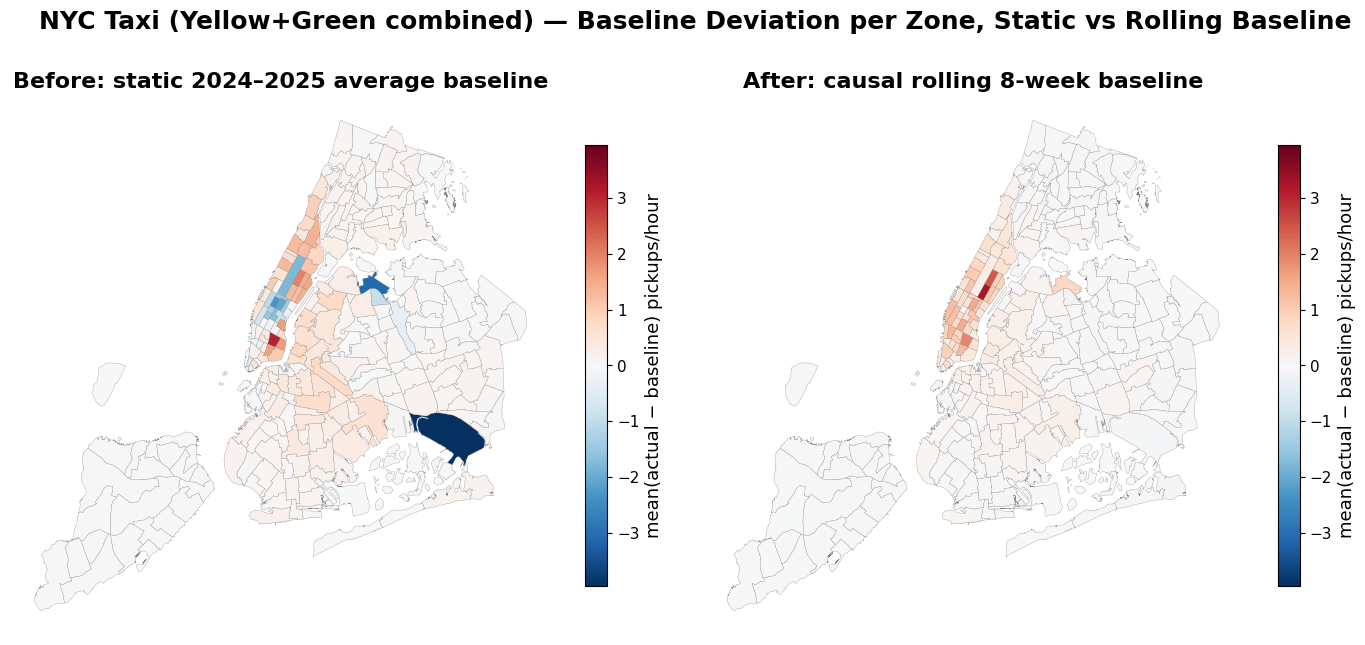

Saved /Users/debaoli/Desktop/nyc-taxi-project/nyc_taxi_demand_prediction_examiner_final/reports/figures/baseline_deviation_static_vs_rolling.png


In [9]:
import matplotlib.pyplot as plt

from src.config import FIGURES_DIR
from src.geospatial import build_zone_choropleth_data, load_taxi_zones

zones = load_taxi_zones()
gdf_static = build_zone_choropleth_data(dev_static, zones, "baseline_deviation")
gdf_rolling = build_zone_choropleth_data(dev_rolling, zones, "baseline_deviation")
vmax = max(gdf_static["baseline_deviation"].abs().max(), gdf_rolling["baseline_deviation"].abs().max())

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
for ax, gdf, title in [
    (axes[0], gdf_static, "Before: static 2024–2025 average baseline"),
    (axes[1], gdf_rolling, "After: causal rolling 8-week baseline"),
]:
    gdf.plot(
        column="baseline_deviation", cmap="RdBu_r", linewidth=0.2, edgecolor="grey",
        legend=True, vmin=-vmax, vmax=vmax,
        legend_kwds={"label": "mean(actual − baseline) pickups/hour", "shrink": 0.7},
        ax=ax,
    )
    # legend_kwds has no fontsize passthrough for the colorbar label -- set it directly
    # on the colorbar's own axis (the one just appended to the figure) to match the
    # fontsize=13/labelsize=11 convention used for axis labels elsewhere in the report.
    cbar_ax = fig.axes[-1]
    cbar_ax.set_ylabel("mean(actual − baseline) pickups/hour", fontsize=13)
    cbar_ax.tick_params(labelsize=11)
    ax.set_title(title, fontsize=16, fontweight="bold")
    ax.set_axis_off()
fig.suptitle(
    "NYC Taxi (Yellow+Green combined) — Baseline Deviation per Zone, Static vs Rolling Baseline",
    y=0.98, fontsize=18, fontweight="bold",
)
fig.tight_layout()

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
out_path = FIGURES_DIR / "baseline_deviation_static_vs_rolling.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {out_path}")

## 7. Section 2.2 — external-join coverage

Joins weather (citywide, on `pickup_hour`), events (expanded to hourly zone cells), and
holidays (on calendar date) onto the rolling-baseline `combined_df` -- the production
pipeline's join, applied to the dataset that actually gets written.

In [10]:
combined_df = join_external_sources(combined_df, spark)
total_rows = combined_df.count()

coverage_row = combined_df.agg(
    F.sum(F.col("tmpf").isNotNull().cast("int")).alias("weather_matched"),
    F.sum(F.col("event_present").cast("int")).alias("event_present_rows"),
    F.sum(F.col("is_holiday").cast("int")).alias("holiday_rows"),
).collect()[0]

external_join_coverage = {
    "total_rows": total_rows,
    "weather_matched_rows": coverage_row["weather_matched"],
    "pct_weather_matched": round(100 * coverage_row["weather_matched"] / total_rows, 4),
    "event_present_rows": coverage_row["event_present_rows"],
    "pct_event_present": round(100 * coverage_row["event_present_rows"] / total_rows, 4),
    "holiday_rows": coverage_row["holiday_rows"],
    "pct_holiday": round(100 * coverage_row["holiday_rows"] / total_rows, 4),
}
print("Section 2.2 -- external-join coverage")
print(f"  Weather join:  {external_join_coverage['pct_weather_matched']}% coverage")
print(f"  Events:        {external_join_coverage['pct_event_present']}% of zone-hours have >= 1 event")
print(f"  Holidays:      {external_join_coverage['pct_holiday']}% of zone-hours")

2026-08-31 04:33:00.521 | INFO     | src.processed:standardise_holiday_schedule:600 - Wrote standardised holiday schedule to /Users/debaoli/Desktop/nyc-taxi-project/nyc_taxi_demand_prediction_examiner_final/data/external/holiday_schedule_clean.csv


Section 2.2 -- external-join coverage
  Weather join:  99.7591% coverage
  Events:        26.9456% of zone-hours have >= 1 event
  Holidays:      2.9478% of zone-hours


## 8. Write Processed dataset + data-quality report

In [11]:
write_processed_zone_hour(combined_df)
write_report(
    results,
    baseline_source_counts=baseline_source_counts,
    external_join_coverage=external_join_coverage,
)
print("Processed dataset + report written.")
spark.stop()

2026-08-31 04:33:54.855 | INFO     | src.processed:write_processed_zone_hour:705 - Wrote combined Processed zone-hour dataset to /Users/debaoli/Desktop/nyc-taxi-project/nyc_taxi_demand_prediction_examiner_final/data/processed/pickups_zone_hour.parquet
2026-08-31 04:33:54.858 | INFO     | src.processed:write_report:746 - Processed data-quality report written to /Users/debaoli/Desktop/nyc-taxi-project/nyc_taxi_demand_prediction_examiner_final/reports/data_quality/processed
Processed dataset + report written.


## 9. Feature-matrix demonstration — zone-identity asymmetry

Per `src/features.py`: Gradient Boosting gets the full `pu_location_id` (263 zones,
native pandas-categorical encoding); Linear/Ridge/LASSO get `borough` (~6 categories,
one-hot) + the baseline instead, to stay interpretable and avoid 263 extra coefficients.

In [12]:
from src.features import build_feature_matrix, split_train_test, split_train_validation
from src.geospatial import load_processed_zone_hour

processed_df = load_processed_zone_hour()
train_df, test_df = split_train_test(processed_df)
train_sub_df, validation_df = split_train_validation(train_df)
print(
    f"Train rows: {len(train_df):,} (fit-sub: {len(train_sub_df):,}, "
    f"validation: {len(validation_df):,}) | Test rows: {len(test_df):,}"
)

X_train_linear, y_train_linear = build_feature_matrix(train_df, "linear")
X_train_gb, y_train_gb = build_feature_matrix(train_df, "gradient_boosting")
print(f"[linear]            X_train {X_train_linear.shape}, y_train {y_train_linear.shape}")
print(f"[gradient_boosting] X_train {X_train_gb.shape}, y_train {y_train_gb.shape}")

Train rows: 9,228,144 (fit-sub: 8,458,080, validation: 770,064) | Test rows: 1,906,224


[linear]            X_train (9215520, 65), y_train (9215520,)
[gradient_boosting] X_train (9215520, 17), y_train (9215520,)


In [13]:
borough_cols_linear = [c for c in X_train_linear.columns if c.startswith("borough_")]

print("Zone-identity asymmetry:")
print(f"  'pu_location_id' in linear feature set:            {'pu_location_id' in X_train_linear.columns}")
print(f"  'pu_location_id' in gradient_boosting feature set: {'pu_location_id' in X_train_gb.columns}")
print(f"  borough_* one-hot columns in linear feature set:   {len(borough_cols_linear)}")
print(f"  borough_* columns in gradient_boosting feature set: "
      f"{len([c for c in X_train_gb.columns if c.startswith('borough_')])}")

Zone-identity asymmetry:
  'pu_location_id' in linear feature set:            False
  'pu_location_id' in gradient_boosting feature set: True
  borough_* one-hot columns in linear feature set:   6
  borough_* columns in gradient_boosting feature set: 0


## Notes

- Output: `data/processed/pickups_zone_hour.parquet` (the unified Yellow+Green zone-hour
  table with rolling baseline + external joins), plus the data-quality report under
  `reports/data_quality/processed/`.
- Figure 1 saved to `reports/figures/baseline_deviation_static_vs_rolling.png`.
- The static baseline (Section 6 above) is recomputed here only for the before/after
  comparison -- it is never written to the Processed dataset or used downstream; the
  production pipeline (and every later notebook) uses the rolling baseline only.
- Table 1's TLC-external row split: this notebook covers the join-coverage percentages
  (Section 2.2); dataset sizes (Table 1) were covered in notebook `03`.